In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.cluster as cluster
from sklearn.decomposition import PCA

In [20]:
df = pd.read_csv("params_df.csv")
df.columns = ["country", "intercept", "tue", "wed", "thu", "fri", "sat", "sun", 
              "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec",
              "hours_1", "hours_2", "hours_3", "hours_4", "hours_5"]
df.set_index(df.iloc[:, 0], inplace = True)
df.drop(df.columns[0], axis = 1, inplace = True)

months = ["feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
days = ["tue", "wed", "thu", "fri", "sat", "sun"]
hours = ["hours_1", "hours_2", "hours_3", "hours_4", "hours_5"]

In [24]:
def get_day_mean(df, day):
    if day =="mon":
        return df["intercept"] + df[hours].mean(axis = 1) + df[months].mean(axis = 1)
    return df["intercept"] + df[day] + df[hours].mean(axis = 1) + df[months].mean(axis = 1)
    
def get_month_mean(df, month):
    if month == "jan":
        return df["intercept"] + df[hours].mean(axis = 1) + df[days].mean(axis = 1)
    return df["intercept"] + df[month] + df[hours].mean(axis = 1) + df[days].mean(axis = 1)

def get_hour_mean(df, hour):
    if hour == "hours_0":
        return df["intercept"] + df[days].mean(axis = 1) + df[months].mean(axis = 1)
    return df["intercept"] + df[hour] + df[days].mean(axis = 1) + df[months].mean(axis = 1)

In [25]:
new_df = df.copy()
new_df["jan"] = get_month_mean(df, "jan")
new_df["mon"] = get_day_mean(df, "mon")
new_df["hours_0"] = get_hour_mean(df, "hours_0")
for day in days:
    new_df[day] = get_day_mean(df, day)
for month in months:
    new_df[month] = get_month_mean(df, month)
for hour in hours:
    new_df[hour] = get_hour_mean(df, hour)

new_df.drop("intercept", axis = 1, inplace = True)

In [36]:
true_months = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
true_hours = ["hours_0", "hours_1", "hours_2", "hours_3", "hours_4", "hours_5"]
true_days = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]

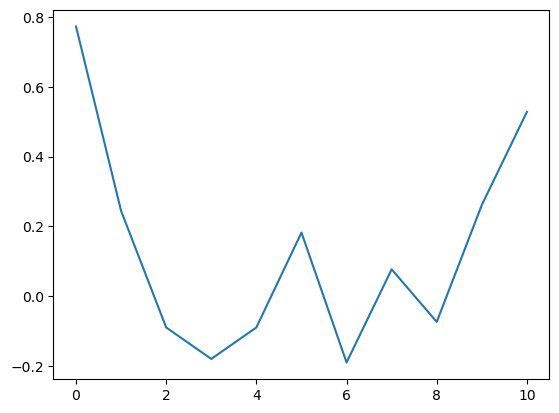

In [43]:
plt.plot(new_df[months][new_df.index == "POR"].to_numpy()[0])

In [47]:
new_df.to_csv( "best_coefficients.csv", index = True)

(25, 23)